# 05. Business Analysis and Customer Segmentation

## Objective

This notebook moves from the statistical findings in Notebook 04 to business-focused analysis.

The main objectives are:

- identify customer segments that deserve attention
- quantify the delivery-related retention gap
- examine customer value alongside delivery performance
- examine freight burden as a descriptive business dimension
- calculate Segment Expected Repeat Revenue
- estimate a scenario-based delivery revenue opportunity
- create business-facing tables and charts

## 1. Setup

In [1]:
from pathlib import Path
import sys
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.config import get_duckdb_path

DUCKDB_PATH = get_duckdb_path()

OUTPUT_DIR = PROJECT_ROOT / "02_Data" / "05_Business_Analysis"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if not DUCKDB_PATH.exists():
    raise FileNotFoundError(
        f"DuckDB database not found: {DUCKDB_PATH}"
    )

con = duckdb.connect(str(DUCKDB_PATH))

print(f"DuckDB version: {duckdb.__version__}")
print(f"Database: {DUCKDB_PATH}")

DuckDB version: 1.5.5
Database: D:\Learning\Data Science\Capstone Project\Final_Project_Olist_BYOC_Capstone\04_DuckDB\olist_capstone.duckdb


## 1a. Load Diagnostic Test Verdicts

Notebook 04 persists its formal test results (significance, direction,
effect size) to a `diagnostic_findings` table. This notebook reads that
table directly.


In [2]:
try:
    diagnostic_findings = con.sql("SELECT * FROM diagnostic_findings").df()
    display(diagnostic_findings)
except Exception as e:
    raise RuntimeError(
        "diagnostic_findings table not found. Run Notebook 04 through its "
        "'Persist Diagnostic Findings' section before running this notebook."
    ) from e

# get_finding() is how downstream charts/text automatically pick up
# Notebook 04's significance verdicts (see NEUTRAL/SIGNAL below) instead of
# hardcoding "is this significant?" a second time in this notebook -- if
# Notebook 04's results ever change, this notebook's charts update with them.

def get_finding(name):
    row = diagnostic_findings.loc[diagnostic_findings["finding"] == name]
    if len(row) == 0:
        return None
    return row.iloc[0]

NEUTRAL = "#B0B0B0"
SIGNAL = "#C0392B"


,finding,p_value,significant,direction,effect_size,effect_size_type
0,H1_late_delivery,0.005944,True,late_worse,0.811026,odds_ratio
1,H2_freight_ratio_band,0.000363,True,high_freight_better,0.576307,pp_difference
2,H2_freight_value_band_corrected,0.968213,False,high_freight_better,0.006459,pp_difference
3,value_tier_interaction,0.340801,False,no_reliable_difference,3.349585,likelihood_ratio_statistic
4,predictive_baseline,NaN,False,weak_discrimination,0.556357,roc_auc


## 2. Validate the Customer-Level Analytical Population

Each row in `customer_level_featured` represents one customer identity in the analytical population.

The repeat-purchase target and first-order features are used for business segmentation.

In [3]:
required_columns = [
    "customer_unique_id",
    "is_repeat_customer",
    "first_order_late_flag",
    "first_order_value",
    "first_order_freight",
    "first_order_freight_ratio",
    "freight_burden_band",
    "value_tier"
]

available_columns = set(
    con.sql("""
        SELECT column_name
        FROM information_schema.columns
        WHERE table_name = 'customer_level_featured'
    """).df()["column_name"]
)

missing_columns = [
    column for column in required_columns
    if column not in available_columns
]

if missing_columns:
    raise ValueError(
        f"Required columns are missing: {missing_columns}"
    )

population_check = con.sql("""
SELECT
    COUNT(*) AS customers,
    COUNT(DISTINCT customer_unique_id) AS unique_customers,
    SUM(is_repeat_customer) AS repeat_customers,
    100.0 * AVG(is_repeat_customer) AS repeat_rate_pct
FROM customer_level_featured
""").df()

display(population_check)

,customers,unique_customers,repeat_customers,repeat_rate_pct
0,93254,93254,2877.0,3.085122


# 3. Customer Value Tier Analysis

The existing customer value tiers are used to remains consistent with the EDA and diagnostic analysis.

The table compares customer size, order value and repeat-purchase behaviour.

In [4]:
value_tier_summary = con.sql("""
SELECT
    value_tier,
    COUNT(*) AS customers,
    SUM(is_repeat_customer) AS repeat_customers,
    100.0 * AVG(is_repeat_customer) AS repeat_rate_pct,
    AVG(first_order_value) AS avg_order_value,
    MEDIAN(first_order_value) AS median_order_value,
    AVG(first_order_freight) AS avg_freight
FROM customer_level_featured
WHERE value_tier IS NOT NULL
GROUP BY value_tier
ORDER BY
    CASE value_tier
        WHEN 'Low' THEN 1
        WHEN 'Medium-Low' THEN 2
        WHEN 'Medium-High' THEN 3
        WHEN 'High' THEN 4
    END
""").df()

display(value_tier_summary)

,value_tier,customers,repeat_customers,repeat_rate_pct,avg_order_value,median_order_value,avg_freight
0,Low,23400,753.0,3.217949,28.613741,29.00,15.217392
1,Medium-Low,23293,755.0,3.241317,63.944420,60.00,18.111460
2,Medium-High,23401,687.0,2.935772,115.103533,113.45,22.813492
3,High,23160,682.0,2.944732,344.036777,230.00,35.066088


# 4. Freight-Burden Analysis

Freight burden is examined as a business segmentation variable.

Notebook 04 found that the observed high-freight group had a higher repeat-purchase rate than the low-freight group. Therefore, this notebook does **not** treat freight as a demonstrated retention-loss or revenue-at-risk lever.

The analysis remains descriptive.

In [5]:
freight_summary = con.sql("""
SELECT
    freight_burden_band,
    COUNT(*) AS customers,
    SUM(is_repeat_customer) AS repeat_customers,
    100.0 * AVG(is_repeat_customer) AS repeat_rate_pct,
    AVG(first_order_value) AS avg_order_value,
    MEDIAN(first_order_value) AS median_order_value,
    AVG(first_order_freight) AS avg_freight,
    AVG(first_order_freight_ratio) AS avg_freight_ratio
FROM customer_level_featured
WHERE freight_burden_band IS NOT NULL
GROUP BY freight_burden_band
ORDER BY
    CASE freight_burden_band
        WHEN 'Low freight burden' THEN 1
        WHEN 'Medium-low freight burden' THEN 2
        WHEN 'Medium-high freight burden' THEN 3
        WHEN 'High freight burden' THEN 4
    END
""").df()

display(freight_summary)

,freight_burden_band,customers,repeat_customers,repeat_rate_pct,avg_order_value,median_order_value,avg_freight,avg_freight_ratio
0,Low freight burden,23325,737.0,3.159700,75.183065,54.99,10.461324,0.248957
1,Medium-low freight burden,23318,785.0,3.366498,90.738365,62.00,15.463404,0.332199
2,Medium-high freight burden,23302,617.0,2.647841,135.037462,98.80,19.785485,0.291594
3,High freight burden,23309,738.0,3.166159,249.016402,149.00,45.403875,0.358731


# 5. Delivery Performance by Customer Value Tier

This section quantifies the observed difference between on-time/early and late first orders within each customer-value tier.

The gap is:

**On-time / early repeat rate − Late repeat rate**

A positive value means the on-time/early group has the higher observed repeat rate.

In [6]:
delivery_by_value = con.sql("""
WITH grouped AS (
    SELECT
        value_tier,

        CASE
            WHEN first_order_late_flag = 1
                THEN 'Late'
            ELSE 'On-time / early'
        END AS delivery_group,

        COUNT(*) AS customers,
        SUM(is_repeat_customer) AS repeat_customers,
        AVG(is_repeat_customer) AS repeat_rate,
        AVG(first_order_value) AS avg_order_value

    FROM customer_level_featured

    WHERE value_tier IS NOT NULL
      AND first_order_late_flag IS NOT NULL
      AND is_repeat_customer IS NOT NULL

    GROUP BY
        value_tier,
        delivery_group
)

SELECT
    value_tier,

    MAX(
        CASE
            WHEN delivery_group = 'On-time / early'
            THEN customers
        END
    ) AS on_time_customers,

    MAX(
        CASE
            WHEN delivery_group = 'Late'
            THEN customers
        END
    ) AS late_customers,

    100.0 * MAX(
        CASE
            WHEN delivery_group = 'On-time / early'
            THEN repeat_rate
        END
    ) AS on_time_repeat_rate_pct,

    100.0 * MAX(
        CASE
            WHEN delivery_group = 'Late'
            THEN repeat_rate
        END
    ) AS late_repeat_rate_pct,

    100.0 * (
        MAX(
            CASE
                WHEN delivery_group = 'On-time / early'
                THEN repeat_rate
            END
        )
        -
        MAX(
            CASE
                WHEN delivery_group = 'Late'
                THEN repeat_rate
            END
        )
    ) AS retention_gap_pp,

    MAX(avg_order_value) AS avg_order_value

FROM grouped

GROUP BY value_tier

ORDER BY
    CASE value_tier
        WHEN 'Low' THEN 1
        WHEN 'Medium-Low' THEN 2
        WHEN 'Medium-High' THEN 3
        WHEN 'High' THEN 4
    END
""").df()

display(delivery_by_value)

,value_tier,on_time_customers,late_customers,on_time_repeat_rate_pct,late_repeat_rate_pct,retention_gap_pp,avg_order_value
0,Low,21674,1726,3.285042,2.375435,0.909607,28.616557
1,Medium-Low,21395,1898,3.243749,3.213909,0.029839,64.025759
2,Medium-High,21499,1902,2.976883,2.471083,0.505800,115.568181
3,High,21094,2066,3.019816,2.178122,0.841694,356.038253


# 6. Late First-Order Exposure

This section shows the size of the late-delivery population within each value tier.

A segment with both a meaningful delivery gap and a large number of late first orders may deserve greater business attention.

In [7]:
delivery_exposure = con.sql("""
SELECT
    value_tier,
    COUNT(*) AS customers,

    SUM(
        CASE
            WHEN first_order_late_flag = 1
            THEN 1 ELSE 0
        END
    ) AS late_first_order_customers,

    100.0 * AVG(
        CASE
            WHEN first_order_late_flag = 1
            THEN 1 ELSE 0
        END
    ) AS late_customer_pct,

    AVG(first_order_value) AS avg_order_value,

    SUM(
        CASE
            WHEN first_order_late_flag = 1
            THEN first_order_value
            ELSE 0
        END
    ) AS first_order_value_exposed

FROM customer_level_featured

WHERE value_tier IS NOT NULL

GROUP BY value_tier

ORDER BY
    CASE value_tier
        WHEN 'Low' THEN 1
        WHEN 'Medium-Low' THEN 2
        WHEN 'Medium-High' THEN 3
        WHEN 'High' THEN 4
    END
""").df()

display(delivery_exposure)

,value_tier,customers,late_first_order_customers,late_customer_pct,avg_order_value,first_order_value_exposed
0,Low,23400,1726.0,7.376068,28.613741,49326.27
1,Medium-Low,23293,1898.0,8.148371,63.944420,121520.89
2,Medium-High,23401,1902.0,8.127858,115.103533,219810.68
3,High,23160,2066.0,8.920553,344.036777,735575.03


# 7. Segment Expected Repeat Revenue

Segment Expected Repeat Revenue is calculated as:

**Average first-order value × historical repeat-purchase rate**

This is an estimate of the expected value represented by one repeat purchase at the segment level.

It is not customer lifetime value and does not represent causal revenue.

In [8]:
# Segment Expected Repeat Revenue = avg order value x historical repeat
# rate -- a deliberately simple expected-value proxy for "what one repeat
# purchase in this segment is worth on average." This is NOT a customer
# lifetime value or discounted-cash-flow model.

segment_expected_repeat_revenue = con.sql("""
SELECT
    value_tier,
    COUNT(*) AS customers,
    AVG(first_order_value) AS avg_order_value,
    100.0 * AVG(is_repeat_customer) AS repeat_rate_pct,

    AVG(first_order_value)
        * AVG(is_repeat_customer)
        AS segment_expected_repeat_revenue

FROM customer_level_featured

WHERE value_tier IS NOT NULL
  AND is_repeat_customer IS NOT NULL
  AND first_order_value IS NOT NULL

GROUP BY value_tier

ORDER BY
    CASE value_tier
        WHEN 'Low' THEN 1
        WHEN 'Medium-Low' THEN 2
        WHEN 'Medium-High' THEN 3
        WHEN 'High' THEN 4
    END
""").df()

display(segment_expected_repeat_revenue)

,value_tier,customers,avg_order_value,repeat_rate_pct,segment_expected_repeat_revenue
0,Low,23400,28.613741,3.217949,0.920775
1,Medium-Low,23293,63.944420,3.241317,2.072641
2,Medium-High,23401,115.103533,2.935772,3.379177
3,High,23160,344.036777,2.944732,10.130962


# 8. Delivery Opportunity by Value Tier

The following calculation estimates the value associated with the observed delivery retention gap.

**Gross delivery opportunity = late customers × average order value × positive retention gap**

This is an analytical opportunity estimate. It should not be interpreted as guaranteed or causal revenue.

In [9]:
# Gross delivery opportunity = late customers x avg order value x the
# POSITIVE part of the retention gap (clip(lower=0) so a tier where late
# customers actually repeat MORE, e.g. Medium-Low, contributes zero rather
# than a negative "opportunity"). This is an illustrative upper bound, not
# a revenue forecast -- see the sensitivity scenarios below.

delivery_opportunity = delivery_by_value.copy()

delivery_opportunity["gross_delivery_opportunity"] = (
    delivery_opportunity["late_customers"]
    * delivery_opportunity["avg_order_value"]
    * (
        delivery_opportunity["retention_gap_pp"].clip(lower=0)
        / 100
    )
)

display(
    delivery_opportunity[
        [
            "value_tier",
            "customers" if "customers" in delivery_opportunity.columns else "on_time_customers",
            "late_customers",
            "avg_order_value",
            "retention_gap_pp",
            "gross_delivery_opportunity"
        ]
    ]
)

,value_tier,on_time_customers,late_customers,avg_order_value,retention_gap_pp,gross_delivery_opportunity
0,Low,21674,1726,28.616557,0.909607,449.274930
1,Medium-Low,21395,1898,64.025759,0.029839,36.260814
2,Medium-High,21499,1902,115.568181,0.505800,1111.801486
3,High,21094,2066,356.038253,0.841694,6191.291530


# 9. Delivery Opportunity Sensitivity Analysis

Because the dataset does not provide an observed intervention effectiveness rate, no single recovery percentage is assumed as fact.

Instead, three illustrative scenarios are shown:

- 10%
- 25%
- 50%

These are sensitivity assumptions only.

In [10]:
# Intervention effectiveness (what fraction of the gap an actual fix could
# recover) is not observable in this dataset, so three illustrative
# scenarios are used instead of one invented "true" number.

EFFECTIVENESS_SCENARIOS = [0.10, 0.25, 0.50]

gross_delivery_opportunity = (
    delivery_opportunity["gross_delivery_opportunity"]
    .sum()
)

delivery_sensitivity = pd.DataFrame({
    "intervention_effectiveness": EFFECTIVENESS_SCENARIOS,
    "gross_delivery_opportunity": gross_delivery_opportunity
})

delivery_sensitivity["scenario_recoverable_revenue"] = (
    delivery_sensitivity["gross_delivery_opportunity"]
    * delivery_sensitivity["intervention_effectiveness"]
)

display(delivery_sensitivity)

,intervention_effectiveness,gross_delivery_opportunity,scenario_recoverable_revenue
0,0.10,7788.62876,778.862876
1,0.25,7788.62876,1947.157190
2,0.50,7788.62876,3894.314380


# 10. Freight Finding for Business Prioritisation

Notebook 04 tested this two ways. The **original ratio-based band**
(`freight_ratio_band`, built on freight ÷ order value) showed high freight
burden associated with a *higher* repeat rate. Because that ratio is
mechanically confounded with order value, Notebook 04 also rebuilt the
band on **absolute freight value** (`freight_burden_band`) and reran the
comparison — see Notebook 04, Section 11b for the side-by-side result and
which direction should be treated as primary.

**This notebook uses `freight_burden_band` (value-based, corrected)
throughout.**

Freight can still be monitored for margin or customer-experience reasons,
but is not treated here as a demonstrated retention-loss lever regardless
of which band is used, since neither showed a robust negative effect
surviving the corrected specification.


In [11]:
freight_comparison = con.sql("""
SELECT
    freight_burden_band,
    COUNT(*) AS customers,
    100.0 * AVG(is_repeat_customer) AS repeat_rate_pct
FROM customer_level_featured
WHERE freight_burden_band IN (
    'Low freight burden',
    'High freight burden'
)
GROUP BY freight_burden_band
ORDER BY freight_burden_band
""").df()

display(freight_comparison)

if len(freight_comparison) == 2:
    low_rate = freight_comparison.loc[
        freight_comparison["freight_burden_band"]
        == "Low freight burden",
        "repeat_rate_pct"
    ].iloc[0]

    high_rate = freight_comparison.loc[
        freight_comparison["freight_burden_band"]
        == "High freight burden",
        "repeat_rate_pct"
    ].iloc[0]

    difference = high_rate - low_rate

    print(
        f"High-freight minus low-freight repeat-rate difference: "
        f"{difference:.2f} percentage points"
    )

    if difference > 0:
        print(
            "The high-freight group has the higher observed repeat rate; "
            "freight is not treated as a retention-loss lever."
        )
    else:
        print(
            "The high-freight group has the lower observed repeat rate."
        )

,freight_burden_band,customers,repeat_rate_pct
0,High freight burden,23309,3.166159
1,Low freight burden,23325,3.159700


High-freight minus low-freight repeat-rate difference: 0.01 percentage points
The high-freight group has the higher observed repeat rate; freight is not treated as a retention-loss lever.


# 11. Business Priority View

The delivery priority combines:

- number of late first-order customers
- delivery retention gap
- average order value
- gross delivery opportunity

This is a decision-support ranking, not a statistical score.

In [12]:
# Composite priority score.

business_priority = delivery_opportunity.copy()

def normalize(series):
    span = series.max() - series.min()
    if span == 0:
        return series * 0
    return (series - series.min()) / span

business_priority["exposure_norm"] = normalize(business_priority["late_customers"])
business_priority["gap_norm"] = normalize(
    business_priority["retention_gap_pp"].clip(lower=0)
)
business_priority["value_norm"] = normalize(business_priority["avg_order_value"])

business_priority["priority_value"] = (
    business_priority["exposure_norm"]
    + business_priority["gap_norm"]
    + business_priority["value_norm"]
) / 3

business_priority = business_priority.sort_values(
    "priority_value",
    ascending=False
)

display(
    business_priority[
        [
            "value_tier",
            "on_time_customers",
            "late_customers",
            "on_time_repeat_rate_pct",
            "late_repeat_rate_pct",
            "retention_gap_pp",
            "avg_order_value",
            "gross_delivery_opportunity",
            "priority_value"
        ]
    ]
)


,value_tier,on_time_customers,late_customers,on_time_repeat_rate_pct,late_repeat_rate_pct,retention_gap_pp,avg_order_value,gross_delivery_opportunity,priority_value
3,High,21094,2066,3.019816,2.178122,0.841694,356.038253,6191.291530,0.974268
2,Medium-High,21499,1902,2.976883,2.471083,0.505800,115.568181,1111.801486,0.441406
0,Low,21674,1726,3.285042,2.375435,0.909607,28.616557,449.274930,0.333333
1,Medium-Low,21395,1898,3.243749,3.213909,0.029839,64.025759,36.260814,0.204676


# 12. Business Visualisations

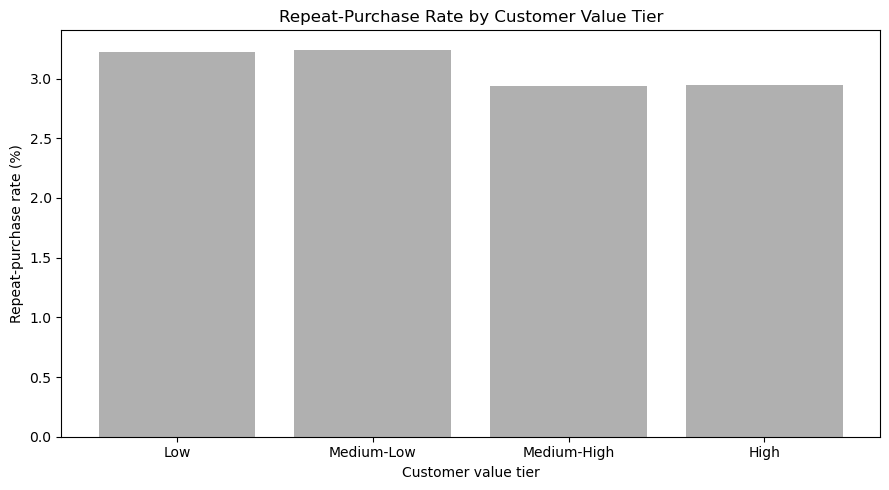

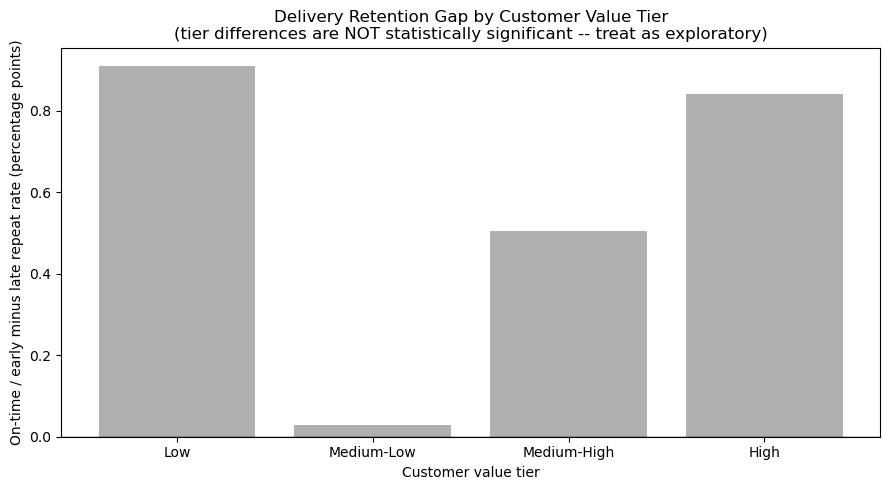

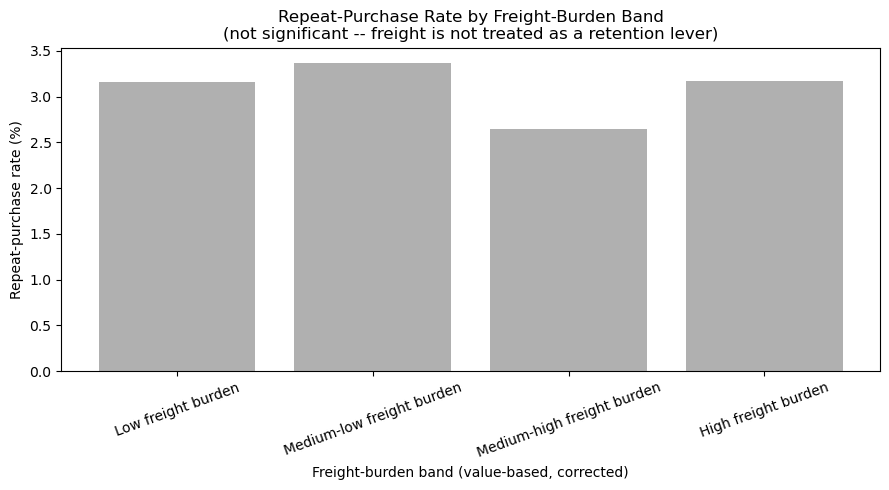

In [13]:
plt.figure(figsize=(9, 5))
plt.bar(
    value_tier_summary["value_tier"],
    value_tier_summary["repeat_rate_pct"],
    color=NEUTRAL,
)
plt.xlabel("Customer value tier")
plt.ylabel("Repeat-purchase rate (%)")
plt.title("Repeat-Purchase Rate by Customer Value Tier")
plt.tight_layout()
plt.show()


# Chart 2: delivery retention gap by value tier.
# Coloured only if Notebook 04's formal interaction test found the
# delivery effect genuinely differs across tiers.
interaction = get_finding("value_tier_interaction")
interaction_significant = bool(interaction["significant"]) if interaction is not None else False

gap_colors = [
    SIGNAL if (interaction_significant and gap > 0) else NEUTRAL
    for gap in delivery_by_value["retention_gap_pp"]
]

plt.figure(figsize=(9, 5))
plt.bar(
    delivery_by_value["value_tier"],
    delivery_by_value["retention_gap_pp"],
    color=gap_colors,
)
plt.axhline(0, linewidth=1, color="black")
plt.xlabel("Customer value tier")
plt.ylabel("On-time / early minus late repeat rate (percentage points)")
subtitle = (
    "tier differences ARE statistically significant (Notebook 04, 11a)"
    if interaction_significant
    else "tier differences are NOT statistically significant -- treat as exploratory"
)
plt.title(f"Delivery Retention Gap by Customer Value Tier\n({subtitle})")
plt.tight_layout()
plt.show()


# Chart 3: repeat rate by freight-burden band (value-based, corrected).
# Coloured only if the corrected (value-based) H2 test was significant.
h2_corrected = get_finding("H2_freight_value_band_corrected")
h2_significant = bool(h2_corrected["significant"]) if h2_corrected is not None else False

band_order = [
    "Low freight burden", "Medium-low freight burden",
    "Medium-high freight burden", "High freight burden",
]
freight_plot_df = freight_summary.set_index("freight_burden_band").reindex(band_order).reset_index()

freight_colors = [NEUTRAL] * len(freight_plot_df)
if h2_significant:
    worse_band = (
        "High freight burden"
        if h2_corrected["direction"] == "high_freight_worse"
        else "Low freight burden"
    )
    worse_idx = freight_plot_df.index[freight_plot_df["freight_burden_band"] == worse_band]
    for idx in worse_idx:
        freight_colors[idx] = SIGNAL

plt.figure(figsize=(9, 5))
plt.bar(
    freight_plot_df["freight_burden_band"],
    freight_plot_df["repeat_rate_pct"],
    color=freight_colors,
)
plt.xlabel("Freight-burden band (value-based, corrected)")
plt.ylabel("Repeat-purchase rate (%)")
freight_subtitle = (
    "significant (Notebook 04, 11b)" if h2_significant else "not significant -- freight is not treated as a retention lever"
)
plt.title(f"Repeat-Purchase Rate by Freight-Burden Band\n({freight_subtitle})")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


# 13. Business Opportunity

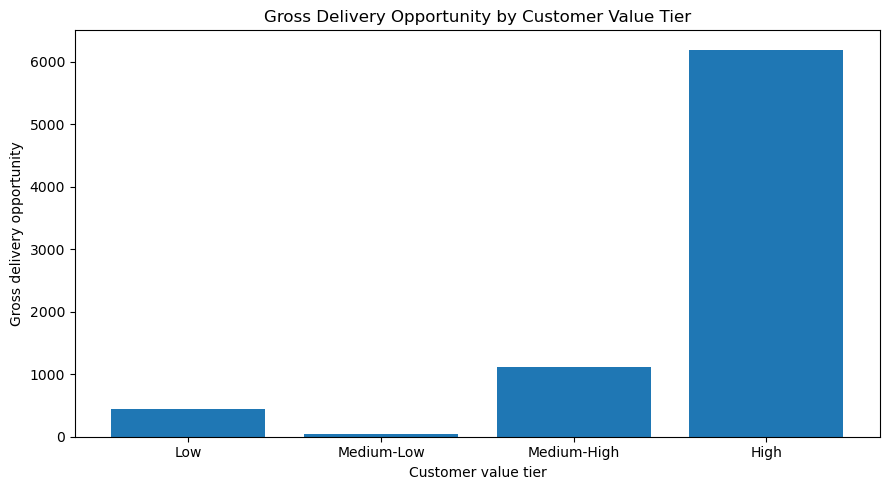

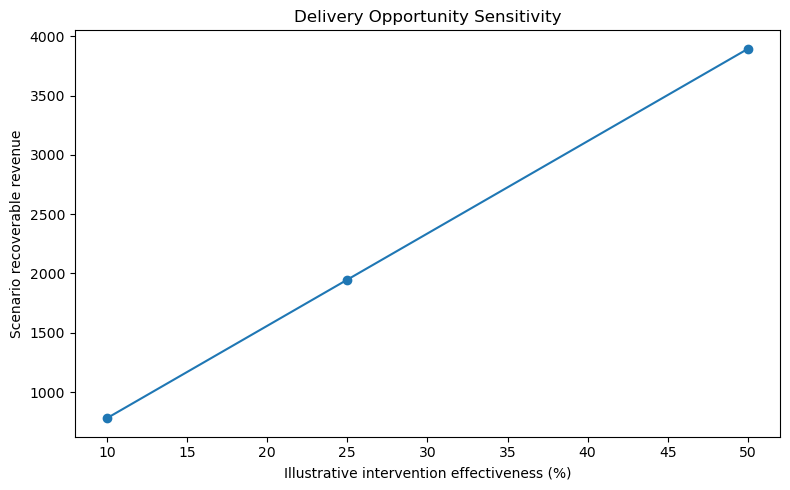

In [14]:
plt.figure(figsize=(9, 5))

plt.bar(
    delivery_opportunity["value_tier"],
    delivery_opportunity["gross_delivery_opportunity"]
)

plt.xlabel("Customer value tier")
plt.ylabel("Gross delivery opportunity")
plt.title("Gross Delivery Opportunity by Customer Value Tier")
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))

plt.plot(
    delivery_sensitivity["intervention_effectiveness"] * 100,
    delivery_sensitivity["scenario_recoverable_revenue"],
    marker="o"
)

plt.xlabel("Illustrative intervention effectiveness (%)")
plt.ylabel("Scenario recoverable revenue")
plt.title("Delivery Opportunity Sensitivity")
plt.tight_layout()
plt.show()

# 14. Descriptive Seller Analysis

Seller-level analysis is included as an exploratory business view.

Only sellers with at least 30 first-order observations are shown to avoid highlighting very small groups.

These results should not be treated as evidence that a seller causes repeat-purchase behaviour.

In [15]:
seller_summary = con.sql("""
WITH first_order_items AS (
    SELECT
        c.order_id,
        c.customer_unique_id,
        c.is_repeat_customer,
        oi.seller_id,
        ROW_NUMBER() OVER (
            PARTITION BY c.order_id
            ORDER BY oi.order_item_id
        ) AS item_rank
    FROM customer_level_featured c
    JOIN order_items_clean oi
        ON c.order_id = oi.order_id
)

SELECT
    seller_id,
    COUNT(*) AS first_orders,
    SUM(is_repeat_customer) AS repeat_customers,
    100.0 * AVG(is_repeat_customer) AS repeat_rate_pct
FROM first_order_items
WHERE item_rank = 1
GROUP BY seller_id
HAVING COUNT(*) >= 30
ORDER BY repeat_rate_pct DESC, first_orders DESC
""").df()

display(seller_summary.head(20))

,seller_id,first_orders,repeat_customers,repeat_rate_pct
0,5b925e1d006e9476d738aa200751b73b,54,9.0,16.666667
1,99a54764c341d5dc80b4a8fac4eba3fb,37,6.0,16.216216
2,4559697a8f7e637227c2eeaed843baff,35,5.0,14.285714
3,efcd8d2104f1a05d028af7bad20d974b,36,5.0,13.888889
4,6fc26fe110feebd80a433e1f012a84f9,30,4.0,13.333333
5,232a6014e7b10cba61c6c2b2ea6bb4b0,32,4.0,12.500000
6,aaed1309374718fdd995ee4c58c9dfcd,98,12.0,12.244898
7,1336efc61c316ddf92c899eb817f7cae,66,8.0,12.121212
8,dc8798cbf453b7e0f98745e396cc5616,35,4.0,11.428571
9,f457c46070d02cadd8a68551231220dd,167,19.0,11.377246


# 15. Descriptive Product-Category Analysis

Product-category analysis provides another descriptive business view.

A customer may have more than one category in the first order, so this table should not be interpreted as a mutually exclusive customer segmentation.

In [16]:
category_summary = con.sql("""
WITH first_order_categories AS (
    SELECT DISTINCT
        c.customer_unique_id,
        c.is_repeat_customer,
        COALESCE(
            p.product_category_english,
            p.product_category_name,
            'Unknown'
        ) AS category
    FROM customer_level_featured c
    JOIN order_items_clean oi
        ON c.order_id = oi.order_id
    LEFT JOIN products_clean p
        ON oi.product_id = p.product_id
)

SELECT
    category,
    COUNT(DISTINCT customer_unique_id) AS customers,
    SUM(is_repeat_customer) AS repeat_customer_records,
    100.0 * AVG(is_repeat_customer) AS repeat_rate_pct
FROM first_order_categories
GROUP BY category
HAVING COUNT(DISTINCT customer_unique_id) >= 100
ORDER BY repeat_rate_pct DESC, customers DESC
""").df()

display(category_summary.head(30))

,category,customers,repeat_customer_records,repeat_rate_pct
0,home_appliances,672,60.0,8.928571
1,fashion_male_clothing,101,7.0,6.930693
2,fashion_bags_accessories,1698,102.0,6.007067
3,fashion_shoes,228,13.0,5.701754
4,home_confort,379,18.0,4.749340
5,furniture_decor,6004,283.0,4.713524
6,air_conditioning,236,11.0,4.661017
7,furniture_living_room,395,18.0,4.556962
8,bed_bath_table,8811,400.0,4.539780
9,fashion_underwear_beach,114,5.0,4.385965


# 16. Export Business Analysis Outputs

In [17]:
exports = {
    "value_tier_summary": value_tier_summary,
    "freight_summary": freight_summary,
    "delivery_by_value": delivery_by_value,
    "delivery_exposure": delivery_exposure,
    "segment_expected_repeat_revenue": segment_expected_repeat_revenue,
    "delivery_opportunity": delivery_opportunity,
    "delivery_sensitivity": delivery_sensitivity,
    "freight_comparison": freight_comparison,
    "business_priority": business_priority,
    "seller_summary": seller_summary,
    "category_summary": category_summary
}

for name, df in exports.items():
    df.to_csv(
        OUTPUT_DIR / f"{name}.csv",
        index=False
    )

print(f"Business analysis outputs saved to: {OUTPUT_DIR}")

Business analysis outputs saved to: d:\Learning\Data Science\Capstone Project\Final_Project_Olist_BYOC_Capstone\02_Data\05_Business_Analysis


# 17. Business Findings Summary

### Delivery

Late first-order delivery was associated with a lower repeat-purchase rate.
This makes delivery performance the primary retention-related business
opportunity examined in this notebook.

### Freight

The high-freight group had a higher observed repeat-purchase rate than the
low-freight group. Therefore freight burden is not presented as a demonstrated
retention-loss driver.

### Customer value

Customer-value tiers help identify where the delivery pattern occurs and
where the combination of customer value, late-order exposure and retention
gap may deserve attention.

### Revenue opportunity

The delivery opportunity is presented as a scenario range rather than a
single forecast because intervention effectiveness is not observed in the
dataset.

# 18. Close DuckDB Connection

In [18]:
con.close()
print("DuckDB connection closed.")

DuckDB connection closed.
